In [56]:

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error
import warnings
import statsmodels.api as sm
import itertools


In [57]:
# Helper function to export and save results as csv after model fitting

def export_and_preview_results(preds, actuals, model_name):
    """
    Displays a preview table and exports the results to CSV.
    """
    # Create the results directory
    Path("results").mkdir(parents=True, exist_ok=True)
    
    # Create the DataFrame
    results_df = pd.DataFrame({
        "Date": preds.index,
        "actual": actuals.values,
        "predicted": preds.values
    })
    
    # Preview
    print(f"\n" + "="*40)
    print(f"   PREVIEW: {model_name} OUTPUT")
    print("="*40)
    # Displaying the top and bottom to check alignment
    print(results_df.head(5))
    print("...")
    print(results_df.tail(5))
    print("="*40)
    
    # Export
    file_name = f"results/{model_name.lower().replace(' ', '_')}_results.csv"
    results_df.to_csv(file_name, index=False)
    print(f"Exported {len(results_df)} rows to: {file_name}\n")
    
    return results_df

In [58]:
 #AR model - tuning to find the best parameters

# Suppress harmless statsmodels warnings inside the loop
warnings.filterwarnings('ignore', 'AutoReg could not use the datetime attributes')

#Expanding Window Function
def run_expanding_window_ar(data, start_idx, end_idx, lags):
    oos_preds = []
    for t in range(start_idx, end_idx):
        train_window = data.iloc[:t]
        model = AutoReg(train_window, lags=lags, old_names=False).fit()
        
        pred = model.predict(start=len(train_window), end=len(train_window)).iloc[0]
        oos_preds.append(pred)
    return pd.Series(oos_preds, index=data.index[start_idx:end_idx])


# Load Data
file_path = Path('data') / 'final_data.csv'
df = pd.read_csv(file_path)

y = df['wti_ret'].dropna()

# Setup the 70/15/15 Split
n = len(y)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

# Define the Grid (Testing 1 to 12 months of lookback)
param_grid_ar = {
    "lookback": [1, 2, 3, 4, 6, 9, 12] 
}

results_grid = []

# Grid Search Loop 
for i, lb in enumerate(param_grid_ar["lookback"], 1):
    print(f"\n[{i}/{len(param_grid_ar['lookback'])}] Testing params: lookback (p) = {lb}")
    
    oos_preds = []
    
    try:
        # Expanding window strictly over the validation set
        for t in range(train_end, val_end):
            train_window = y.iloc[:t]
            model = AutoReg(train_window, lags=lb, old_names=False).fit()
            pred = model.predict(start=len(train_window), end=len(train_window)).iloc[0]
            oos_preds.append(pred)
            
        # Calculate Validation MSE
        actuals = y.iloc[train_end:val_end]
        mse = mean_squared_error(actuals, oos_preds)
        
        print(f"Validation MSE: {mse:.6f}")
        
        
        results_grid.append({
            "lookback (p)": lb,
            "mse": mse
        })
        
    except Exception as e:
        print(f"Error at lookback {lb}: {e}")
        continue

# Display best parameters
results_df = pd.DataFrame(results_grid).sort_values("mse")


print("AR GRID SEARCH RESULTS (RANKED)")
print(results_df.to_string(index=False))


best_p = results_df.iloc[0]['lookback (p)']

print(f"AR({best_p}) to be used")



[1/7] Testing params: lookback (p) = 1


Validation MSE: 0.007331

[2/7] Testing params: lookback (p) = 2
Validation MSE: 0.007372

[3/7] Testing params: lookback (p) = 3
Validation MSE: 0.007316

[4/7] Testing params: lookback (p) = 4
Validation MSE: 0.007353

[5/7] Testing params: lookback (p) = 6
Validation MSE: 0.007772

[6/7] Testing params: lookback (p) = 9
Validation MSE: 0.007670

[7/7] Testing params: lookback (p) = 12
Validation MSE: 0.007647
AR GRID SEARCH RESULTS (RANKED)
 lookback (p)      mse
            3 0.007316
            1 0.007331
            4 0.007353
            2 0.007372
           12 0.007647
            9 0.007670
            6 0.007772
AR(3.0) to be used



VALIDATION SET RESULTS
MSE  : 0.007316 | RMSE : 0.085533
MAE  : 0.067893 | MAPE : 278.11%
R^2  : 0.067973 | DA   : 54.17%

TESTING SET 
MSE  : 0.018401 | RMSE : 0.135649
MAE  : 0.080605 | MAPE : 124.04%
R^2  : 0.028882 | DA   : 62.50%


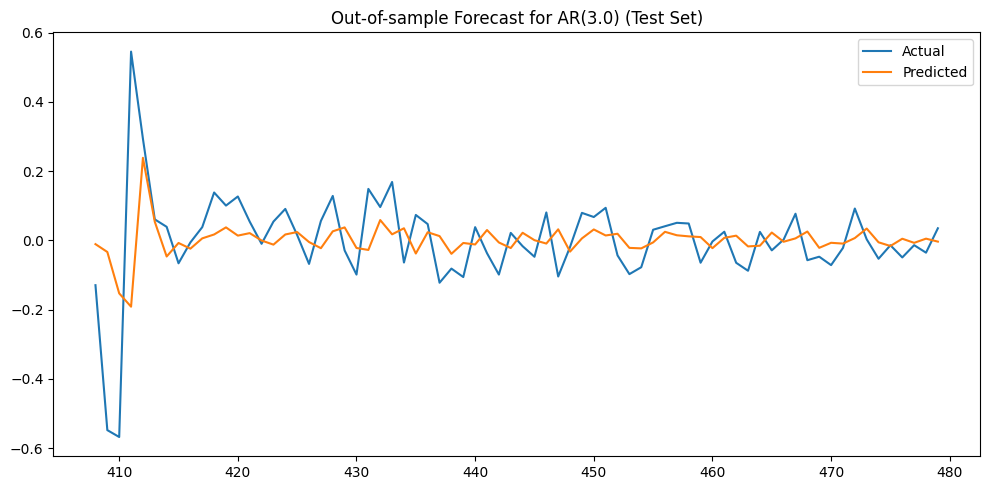

In [59]:

# AR model - model fitting and OOS performance evaluation



# Metrics Calculation Function
def get_all_metrics(actuals, preds):
    res = actuals - preds
    mse = np.mean(res**2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(res))
    safe_actuals = np.where(actuals == 0, np.nan, actuals)
    mape = np.nanmean(np.abs(res / safe_actuals)) * 100
    ss_res = np.sum(res**2)
    ss_tot = np.sum((actuals - np.mean(actuals))**2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0 
    da = np.mean(np.sign(actuals) == np.sign(preds)) * 100
    return {"MSE": mse, "RMSE": rmse, "MAE": mae, "MAPE": mape, "R2": r2, "DA": da}

# Fallback for parameter
if 'best_p' not in locals():
    print("Warning: best_p not found in memory. Defaulting to 3.")
    best_p = 3  


val_preds_final = run_expanding_window_ar(y, train_end, val_end, lags=best_p)
test_preds_final = run_expanding_window_ar(y, val_end, len(y), lags=best_p)

# Align actuals
val_actuals = y.loc[val_preds_final.index]
test_actuals = y.loc[test_preds_final.index]

# Calculate and print Metrics
val_metrics = get_all_metrics(val_actuals, val_preds_final)
test_metrics = get_all_metrics(test_actuals, test_preds_final)

def print_metrics_block(title, m):
    print(f"\n{title}")
    print(f"MSE  : {m['MSE']:.6f} | RMSE : {m['RMSE']:.6f}")
    print(f"MAE  : {m['MAE']:.6f} | MAPE : {m['MAPE']:.2f}%")
    print(f"R^2  : {m['R2']:.6f} | DA   : {m['DA']:.2f}%")
    

print_metrics_block("VALIDATION SET RESULTS", val_metrics)
print_metrics_block("TESTING SET ", test_metrics)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(test_actuals.index, test_actuals, label='Actual', color='#1f77b4')
ax.plot(test_preds_final.index, test_preds_final, label='Predicted', color='#ff7f0e')
ax.set_title(f'Out-of-sample Forecast for AR({best_p}) (Test Set)', fontsize=12)
ax.legend(loc='upper right')
ax.grid(False) 
plt.tight_layout()
plt.show()

# export and save results as csv
#ar_results = export_and_preview_results(test_preds_final, test_actuals, f"AR(3)_benchmark")

In [60]:
# ADL - tuning the model to find best parameters

warnings.filterwarnings('ignore')

#file_path = Path('data') / 'final_data.csv'
#df = pd.read_csv(file_path)

tb_col = 'TB3MS'

# Cap search to 2
max_p = 2  
max_q = 2  

model_data = pd.DataFrame({'Y_t': df['wti_ret']})

for i in range(1, max_p + 1):
    model_data[f'Y_lag_{i}'] = df['wti_ret'].shift(i)
for i in range(1, max_q + 1):
    model_data[f'X_lag_{i}'] = df[tb_col].shift(i)

model_data = model_data.dropna()

n = len(model_data)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

# Expanding window function for adl
def run_adl_expanding_window(data, start_idx, end_idx, p, q):
    features = [f'Y_lag_{i}' for i in range(1, p + 1)] + [f'X_lag_{i}' for i in range(1, q + 1)]
    oos_preds = []
    
    for t in range(start_idx, end_idx):
        train_window = data.iloc[:t]
        
        X_train = sm.add_constant(train_window[features])
        Y_train = train_window['Y_t']
        
        model = sm.OLS(Y_train, X_train).fit()
        
        # Safe slicing to extract a 1-row DataFrame directly
        X_test = sm.add_constant(data[features].iloc[t:t+1], has_constant='add')
        
        if 'const' not in X_test.columns:
            X_test.insert(0, 'const', 1.0)
            
        pred = model.predict(X_test).iloc[0]
        oos_preds.append(pred)
        
    return pd.Series(oos_preds, index=data.index[start_idx:end_idx])

# Parameter tuning

print("ADL(p,q) PARAMETER TUNING (VALIDATION MSE)")


# Grid
param_grid = {
    "p": [1, 2], 
    "q": [1, 2]  
}
param_combinations = list(itertools.product(param_grid["p"], param_grid["q"]))

tuning_results = []

for p, q in param_combinations:
    try:
        val_preds_temp = run_adl_expanding_window(model_data, train_end, val_end, p, q)
        actuals_temp = model_data['Y_t'].loc[val_preds_temp.index]
        
        mse = np.mean((actuals_temp - val_preds_temp)**2)
        tuning_results.append({"p": p, "q": q, "mse": mse})
        print(f"Testing ADL(p={p}, q={q}) | Validation MSE: {mse:.6f}")
        
    except Exception as e:
        print(f"Testing ADL(p={p}, q={q}) | Failed Error: {e}")

# Error handling and results
if not tuning_results:
    print("\n ERROR: All models failed. Check the error messages above.")
else:
    results_df = pd.DataFrame(tuning_results).sort_values("mse")
    best_p = int(results_df.iloc[0]["p"])
    best_q = int(results_df.iloc[0]["q"])
    print(f"Model set to ADL({best_p}, {best_q}).")

ADL(p,q) PARAMETER TUNING (VALIDATION MSE)
Testing ADL(p=1, q=1) | Validation MSE: 0.007455
Testing ADL(p=1, q=2) | Validation MSE: 0.007455
Testing ADL(p=2, q=1) | Validation MSE: 0.007488
Testing ADL(p=2, q=2) | Validation MSE: 0.007491
Model set to ADL(1, 1).


VALIDATION SET (70% - 85%)
MSE  : 0.007455
RMSE : 0.086342
MAE  : 0.068329
MAPE : 270.55%
R^2  : 0.050271
DA   : 54.17%
TESTING SET (85% - 100%)
MSE  : 0.018756
RMSE : 0.136952
MAE  : 0.083036
MAPE : 116.42%
R^2  : 0.010140
DA   : 58.33%


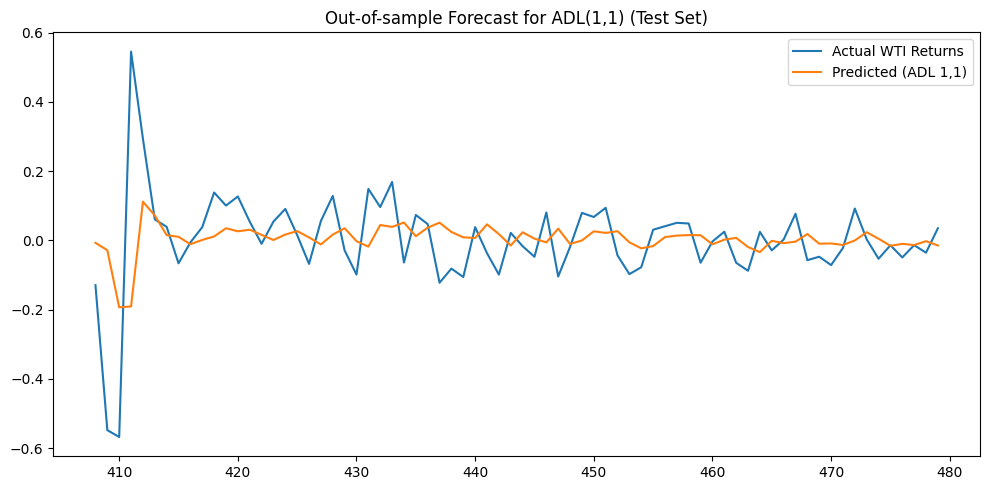

In [61]:

# ADL(1,1) - model fitting and OOS performance evaluation
# Metrics
def get_all_metrics(actuals, preds):
    res = actuals - preds
    mse = np.mean(res**2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(res))
    
    safe_actuals = np.where(actuals == 0, np.nan, actuals)
    mape = np.nanmean(np.abs(res / safe_actuals)) * 100
    
    ss_res = np.sum(res**2)
    ss_tot = np.sum((actuals - np.mean(actuals))**2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0 
    
    da = np.mean(np.sign(actuals) == np.sign(preds)) * 100
    return {"MSE": mse, "RMSE": rmse, "MAE": mae, "MAPE": mape, "R2": r2, "DA": da}

# OOS performance evaluation
val_preds_final = run_adl_expanding_window(model_data, train_end, val_end, best_p, best_q)
test_preds_final = run_adl_expanding_window(model_data, val_end, n, best_p, best_q)

# Align actuals
val_actuals = model_data['Y_t'].loc[val_preds_final.index]
test_actuals = model_data['Y_t'].loc[test_preds_final.index]

val_metrics = get_all_metrics(val_actuals, val_preds_final)
test_metrics = get_all_metrics(test_actuals, test_preds_final)

def print_metrics_block(title, m):
    print(title)
    
    print(f"MSE  : {m['MSE']:.6f}")
    print(f"RMSE : {m['RMSE']:.6f}")
    print(f"MAE  : {m['MAE']:.6f}")
    print(f"MAPE : {m['MAPE']:.2f}%")
    print(f"R^2  : {m['R2']:.6f}")
    print(f"DA   : {m['DA']:.2f}%")
    

print_metrics_block("VALIDATION SET (70% - 85%)", val_metrics)
print_metrics_block("TESTING SET (85% - 100%)", test_metrics)

#Plot
fig, ax = plt.subplots(figsize=(10, 5))


ax.plot(test_actuals.index, test_actuals, label='Actual WTI Returns', color='#1f77b4')
ax.plot(test_preds_final.index, test_preds_final, label=f'Predicted (ADL {best_p},{best_q})', color='#ff7f0e')

ax.set_title(f'Out-of-sample Forecast for ADL({best_p},{best_q}) (Test Set)', fontsize=12)
ax.legend(loc='upper right')


ax.grid(False) 
ax.set_xlabel('')
ax.set_ylabel('')

plt.tight_layout()
plt.show()

#export and save results as csv
#test_preds_adl_simple = test_preds_final
#test_actuals_adl_simple = test_actuals
#export_and_preview_results(test_preds_adl_simple, test_actuals_adl_simple, "ADL(1,1)_benchmark")

In [62]:
#Full ADL with 8 covariates - tuning the model to pick best parameters


# Target and all 8 Covariates
# Adjust exact column names here if your CSV capitalization is slightly different
all_features = [
    'wti_ret', 'AUD_USD_ret', 'CAD_USD_ret', 'NZD_USD_ret', 
    'ZAR_USD_ret', 'CPI', 'TB3MS', 'M1', 'M2'
]

# Ensure TB3MS matches case just in case
if 'tb3ms' in df.columns and 'TB3MS' not in df.columns:
    all_features[all_features.index('TB3MS')] = 'tb3ms'

max_lookback = 2  

model_data = pd.DataFrame({'Y_t': df['wti_ret']})

# Generate lags for ALL 9 variables simultaneously
for feat in all_features:
    for i in range(1, max_lookback + 1):
        model_data[f'{feat}_lag_{i}'] = df[feat].shift(i)

# Drop NaNs ONCE to align the timeline perfectly
model_data = model_data.dropna()

n = len(model_data)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

#full adl expanding window funcion
def run_full_adl_window(data, start_idx, end_idx, lookback):
    active_features = []
    for feat in all_features:
        for i in range(1, lookback + 1):
            active_features.append(f'{feat}_lag_{i}')
            
    oos_preds = []
    
    for t in range(start_idx, end_idx):
        train_window = data.iloc[:t]
        
        X_train = sm.add_constant(train_window[active_features])
        Y_train = train_window['Y_t']
        
        model = sm.OLS(Y_train, X_train).fit()
        
        # Safely slice the 1-row DataFrame for the test step
        X_test = sm.add_constant(data[active_features].iloc[t:t+1], has_constant='add')
        
        if 'const' not in X_test.columns:
            X_test.insert(0, 'const', 1.0)
            
        pred = model.predict(X_test).iloc[0]
        oos_preds.append(pred)
        
    return pd.Series(oos_preds, index=data.index[start_idx:end_idx])

# Parameter tuning (global lookback)

print("FULL ADL TUNING (VALIDATION MSE)")
tuning_results = []
lookbacks_to_test = [1, 2]

for lb in lookbacks_to_test:
    try:
        val_preds_temp = run_full_adl_window(model_data, train_end, val_end, lb)
        actuals_temp = model_data['Y_t'].loc[val_preds_temp.index]
        
        mse = np.mean((actuals_temp - val_preds_temp)**2)
        tuning_results.append({"lookback": lb, "mse": mse})
        print(f"Testing Global Lookback = {lb} | Validation MSE: {mse:.6f}")
        
    except Exception as e:
        print(f"Testing Global Lookback = {lb} | Failed Error: {e}")

# Save winning parameter
results_df = pd.DataFrame(tuning_results).sort_values("mse")
best_lb = int(results_df.iloc[0]["lookback"])
print(f"Model set to {best_lb} lag per covariate.")

   FULL ADL TUNING (VALIDATION MSE)
Testing Global Lookback = 1 | Validation MSE: 0.007291
Testing Global Lookback = 2 | Validation MSE: 0.007729
Model set to 1 lag per covariate.


VALIDATION SET (70% - 85%)
MSE  : 0.007291
RMSE : 0.085390
MAE  : 0.067847
MAPE : 281.10%
R^2  : 0.071093
DA   : 55.56%
TESTING SET (85% - 100%)
MSE  : 0.023143
RMSE : 0.152128
MAE  : 0.090870
MAPE : 129.14%
R^2  : -0.221398
DA   : 51.39%


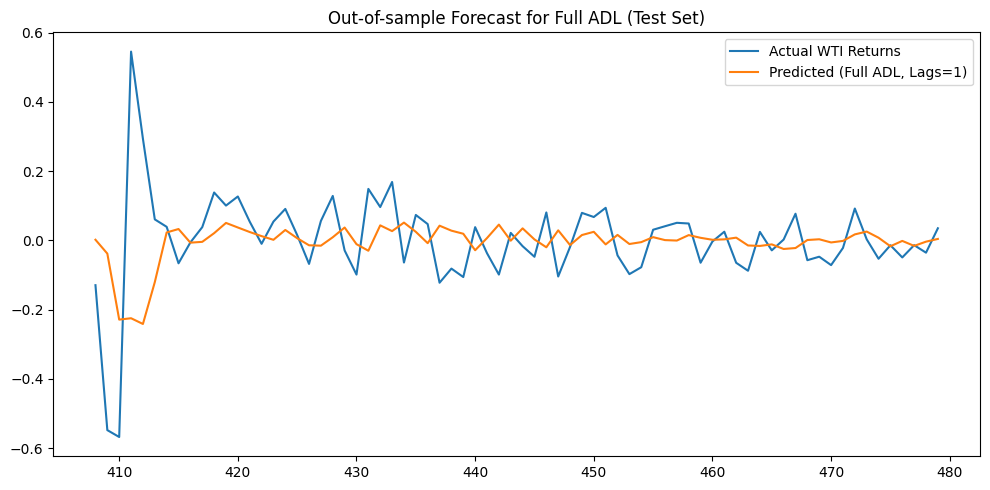

In [63]:
#full ADL - model fitting and OOS performance evaluation

# Metrics
def get_all_metrics(actuals, preds):
    res = actuals - preds
    mse = np.mean(res**2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(res))
    
    safe_actuals = np.where(actuals == 0, np.nan, actuals)
    mape = np.nanmean(np.abs(res / safe_actuals)) * 100
    
    ss_res = np.sum(res**2)
    ss_tot = np.sum((actuals - np.mean(actuals))**2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0 
    
    da = np.mean(np.sign(actuals) == np.sign(preds)) * 100
    return {"MSE": mse, "RMSE": rmse, "MAE": mae, "MAPE": mape, "R2": r2, "DA": da}

# OOS performance evaluation


val_preds_final = run_full_adl_window(model_data, train_end, val_end, best_lb)
test_preds_final = run_full_adl_window(model_data, val_end, n, best_lb)

# Align actuals
val_actuals = model_data['Y_t'].loc[val_preds_final.index]
test_actuals = model_data['Y_t'].loc[test_preds_final.index]

val_metrics = get_all_metrics(val_actuals, val_preds_final)
test_metrics = get_all_metrics(test_actuals, test_preds_final)

def print_metrics_block(title, m):
    print(title)
    print(f"MSE  : {m['MSE']:.6f}")
    print(f"RMSE : {m['RMSE']:.6f}")
    print(f"MAE  : {m['MAE']:.6f}")
    print(f"MAPE : {m['MAPE']:.2f}%")
    print(f"R^2  : {m['R2']:.6f}")
    print(f"DA   : {m['DA']:.2f}%")
    

print_metrics_block("VALIDATION SET (70% - 85%)", val_metrics)
print_metrics_block("TESTING SET (85% - 100%)", test_metrics)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(test_actuals.index, test_actuals, label='Actual WTI Returns', color='#1f77b4')
ax.plot(test_preds_final.index, test_preds_final, label=f'Predicted (Full ADL, Lags={best_lb})', color='#ff7f0e')

ax.set_title(f'Out-of-sample Forecast for Full ADL (Test Set)', fontsize=12)
ax.legend(loc='upper right')

ax.grid(False) 
ax.set_xlabel('')
ax.set_ylabel('')

plt.tight_layout()
plt.show()



#export and save results as csv

#test_preds_adl_full = test_preds_final
#test_actuals_adl_full = test_actuals
#export_and_preview_results(test_preds_adl_full, test_actuals_adl_full, "ADL(all 8 covariates)_benchmark")